In [1]:
import os
import sys
from pathlib import Path

import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if (ROOT / "src").exists():
    repo_root = ROOT
elif (ROOT.parent / "src").exists():
    repo_root = ROOT.parent
elif (ROOT.parent.parent / "src").exists():
    repo_root = ROOT.parent.parent
else:
    repo_root = ROOT

sys.path.append(str(repo_root / "src"))

print("Repo root:", repo_root)
print("Src path added:", repo_root / "src")

Repo root: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs
Src path added: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/src


In [2]:
data_dir = repo_root / "data" / "raw" / "task2"
moon_path = data_dir / "Moon.png"
deep_sky_path = data_dir / "EX3_01.png"

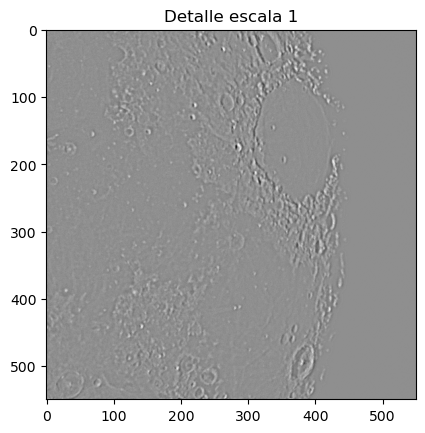

In [4]:
from skimage.io import imread
import matplotlib.pyplot as plt
from course_utils.starlet2d import starlet_transform

img = imread(moon_path, as_gray=True)

coeffs, cJ = starlet_transform(img, n_scales=5)

plt.imshow(coeffs[0], cmap='gray')
plt.title("Detalle escala 1")
plt.show()

(550, 550) (550, 550)
max reconstruction error: 2.220446049250313e-16


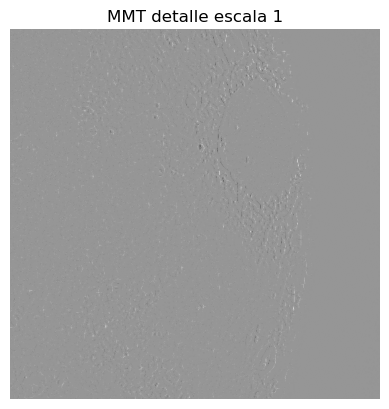

In [5]:
from skimage.io import imread
import matplotlib.pyplot as plt
from course_utils.mmt2d import mmt_transform, mmt_reconstruction

img = imread(moon_path, as_gray=True)

details, cJ, approximations = mmt_transform(
    img,
    n_scales=5,
    kernel_type="diamond",
    base_radius=1,
)

rec = mmt_reconstruction(details, cJ)

print(img.shape, rec.shape)
print("max reconstruction error:", abs(img - rec).max())

plt.imshow(details[0], cmap="gray")
plt.title("MMT detalle escala 1")
plt.axis("off")
plt.show()